# PR-8: Expanded Synthetic Probes

Three additions from PR-8:

| Addition | Key | Purpose |
|---|---|---|
| NaN masking | all conditional features | `generate_composite_dataset` uses NaN as absent-concept sentinel; probes now filter per-feature |
| Binary AUROC | `spike_present`, `rw_present` | AUROC is more robust than accuracy under class imbalance |
| `spike_patch_idx` per-patch | per-patch probe | localization: does the model know *where* in the context the spike landed? |

**Scientific questions answered here:**

1. How many examples in the composite dataset have each concept? (Motivates NaN masking.)
2. Do conditional feature scores (ar_phi, level_magnitude, …) come out finite and above-chance after masking?
3. Is AUROC notably different from accuracy for spike_present / rw_present?
4. Does the per-patch heatmap for spike_patch_idx show the spike position concentrated near the correct patch?

## Running

**Option A** — Load pre-computed JSONs (run `train_probes.py` first):
```bash
python -m experiments.mech_interp.block1_probing.train_probes \
    --moiraie-ckpt <path> --moiraic-ckpt <path> --per-patch
```

**Option B** — Run inline with tiny in-memory models (fast, shows structure only).

In [1]:
import glob
import json
import math
import os
import sys

import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np
import pandas as pd

REPO_ROOT = os.path.abspath(os.path.join(os.getcwd(), '..', '..', '..'))
if REPO_ROOT not in sys.path:
    sys.path.insert(0, REPO_ROOT)

plt.rcParams.update({'figure.dpi': 120, 'font.size': 11})

NOTEBOOK_DIR = os.path.dirname(os.path.abspath('__file__'))
RESULTS_DIR  = os.path.join(NOTEBOOK_DIR, 'results', 'synthetic')
FIGURES_DIR  = os.path.join(NOTEBOOK_DIR, 'figures', 'pr8')
os.makedirs(FIGURES_DIR, exist_ok=True)

CKPT = {
    'moiraie': '/srv/disk00/ctadler/uni2ts/outputs/pretrain/moiraie/gift_eval_pretrain_weighted/moiraie_training_7/HF_checkpoints/last',
    'moiraic': '/srv/disk00/ctadler/uni2ts/outputs/pretrain/moiraic/gift_eval_pretrain_weighted/moiraic_training_11/HF_checkpoints/last',
}

print(f'Results dir : {RESULTS_DIR}')
print(f'Figures dir : {FIGURES_DIR}')

Results dir : /srv/disk00/ctadler/uni2ts/experiments/mech_interp/block1_probing/results/synthetic
Figures dir : /srv/disk00/ctadler/uni2ts/experiments/mech_interp/block1_probing/figures/pr8


## Helper functions

In [2]:
from experiments.mech_interp.block1_probing.train_probes import (
    REGRESSION_FEATURES, BINARY_FEATURES, CLASSIFICATION_FEATURES,
    PATCH_SIZE, CONTEXT_PATCHES, PRED_PATCHES,
)

# Feature metadata for plotting (baseline, metric label)
FEATURE_META = {
    **{f: {'type': 'regression',      'baseline': 0.0, 'metric': 'R²'}    for f in REGRESSION_FEATURES},
    **{f: {'type': 'binary',          'baseline': 0.5, 'metric': 'AUROC'} for f in BINARY_FEATURES},
    'period_idx':      {'type': 'classification', 'baseline': 1/8,  'metric': 'Accuracy'},
    'spike_patch_idx': {'type': 'classification', 'baseline': 1/32, 'metric': 'Accuracy'},
}

# Conditional features (NaN when concept absent)
CONDITIONAL_FEATURES = [
    'level_magnitude', 'level_time_norm',
    'ar_phi',
    'seasonal_amplitude', 'phase_cos', 'phase_sin',
    'log_sigma_ratio', 'var_shift_time_norm',
]

POOLING_MODES  = ('mean_ctx', 'last_ctx')
POOLING_LS     = {'mean_ctx': '-', 'last_ctx': '--'}

prop_cycle = plt.rcParams['axes.prop_cycle'].by_key()['color']


def load_probe_json(path):
    """Load {pooling: {feature: {layer_str: score}}} and convert layer keys to int."""
    with open(path) as f:
        raw = json.load(f)
    return {
        pooling: {feat: {int(k): v for k, v in layers.items()}
                  for feat, layers in feat_dict.items()}
        for pooling, feat_dict in raw.items()
    }


def load_per_patch_json(path):
    """Load {feature: {layer_str: {patch_str: score}}} with int-converted keys."""
    with open(path) as f:
        raw = json.load(f)
    return {
        feat: {int(l): {int(p): v for p, v in patch_dict.items()}
               for l, patch_dict in layer_dict.items()}
        for feat, layer_dict in raw.items()
    }


def layer_x(layer_keys):
    """Return (sorted_keys, x_positions, tick_labels). Key -1 labelled 'embed'."""
    keys   = sorted(layer_keys)
    xpos   = list(range(len(keys)))
    labels = ['embed\n(-1)' if k == -1 else str(k) for k in keys]
    return keys, xpos, labels


print('Helpers defined.')

Helpers defined.


## 1 · Composite dataset composition

Shows how many of the 5000 examples have each concept active.  
Conditional features use NaN as the absent sentinel — this is why NaN masking is essential.

Generating composite dataset (n=5000, seed=42)...
  Dataset keys : ['series', 'concept_mask', 'log_noise_var', 'slope', 'level_magnitude', 'level_time_norm', 'ar_phi', 'period_idx', 'seasonal_amplitude', 'phase_cos', 'phase_sin', 'log_sigma_ratio', 'var_shift_time_norm', 'spike_present', 'spike_patch_idx', 'rw_present']
  n = 5000
Saved /srv/disk00/ctadler/uni2ts/experiments/mech_interp/block1_probing/figures/pr8/dataset_composition.pdf


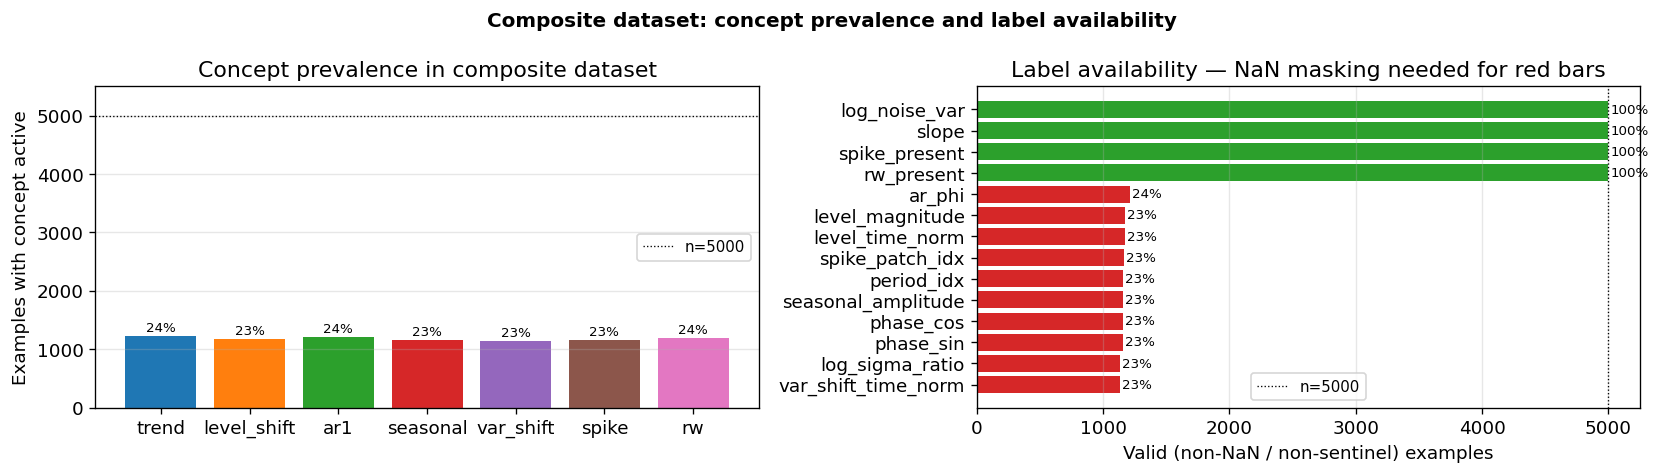

In [3]:
from experiments.mech_interp.lib import generate_composite_dataset

print('Generating composite dataset (n=5000, seed=42)...')
dataset = generate_composite_dataset(n=5000, seed=42)
n = len(dataset['series'])
print(f'  Dataset keys : {list(dataset.keys())}')
print(f'  n = {n}')

# ── Concept presence counts ──────────────────────────────────────────────────
concept_names  = ['trend', 'level_shift', 'ar1', 'seasonal', 'var_shift', 'spike', 'rw']
concept_counts = dataset['concept_mask'].sum(axis=0)

# ── Valid examples per label (after NaN / sentinel masking) ──────────────────
label_keys = [k for k in dataset if k not in ('series', 'concept_mask')]
label_valid = {}
for k in label_keys:
    arr = dataset[k]
    if np.issubdtype(arr.dtype, np.floating):
        label_valid[k] = int(np.isfinite(arr).sum())
    elif k == 'period_idx':
        label_valid[k] = int((arr >= 0).sum())
    elif k == 'spike_patch_idx':
        label_valid[k] = int((arr >= 0).sum())
    else:
        label_valid[k] = n  # always defined

# ── Plot ─────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Left: concept presence
ax = axes[0]
bars = ax.bar(concept_names, concept_counts, color=prop_cycle[:7])
ax.axhline(n, color='black', linestyle=':', linewidth=0.8, label=f'n={n}')
ax.set_ylabel('Examples with concept active')
ax.set_title('Concept prevalence in composite dataset')
ax.legend(fontsize=9)
ax.set_ylim(0, n * 1.1)
for bar, cnt in zip(bars, concept_counts):
    ax.text(bar.get_x() + bar.get_width()/2, cnt + 30,
            f'{cnt/n:.0%}', ha='center', va='bottom', fontsize=8)
ax.grid(True, axis='y', alpha=0.3)

# Right: valid examples per label
ax = axes[1]
keys_sorted = sorted(label_valid, key=lambda k: -label_valid[k])
colors = ['#2ca02c' if label_valid[k] == n else '#d62728' for k in keys_sorted]
bars2 = ax.barh(keys_sorted, [label_valid[k] for k in keys_sorted], color=colors)
ax.axvline(n, color='black', linestyle=':', linewidth=0.8, label=f'n={n}')
ax.set_xlabel('Valid (non-NaN / non-sentinel) examples')
ax.set_title('Label availability — NaN masking needed for red bars')
ax.legend(fontsize=9)
ax.invert_yaxis()
for bar, k in zip(bars2, keys_sorted):
    v = label_valid[k]
    ax.text(v + 20, bar.get_y() + bar.get_height()/2,
            f'{v/n:.0%}', ha='left', va='center', fontsize=8)
ax.grid(True, axis='x', alpha=0.3)

fig.suptitle('Composite dataset: concept prevalence and label availability', fontsize=12, fontweight='bold')
plt.tight_layout()
path = os.path.join(FIGURES_DIR, 'dataset_composition.pdf')
fig.savefig(path, bbox_inches='tight')
print(f'Saved {path}')
plt.show()
plt.close(fig)

## 2 · Load or run probes

Tries `results/synthetic/{model}.json` first; falls back to inline tiny models.

In [4]:
import torch
from experiments.mech_interp.block1_probing.train_probes import (
    run_probes_for_model, run_probes_per_patch,
)

rng_np = np.random.default_rng(42)
idx = rng_np.permutation(n)
train_idx, val_idx = idx[:4000], idx[4000:]

results     = {}   # {model_name: {pooling: {feat: {layer: score}}}}
pp_results  = {}   # {model_name: {feat: {layer: {patch: score}}}}

# ── Try loading pre-computed JSONs ───────────────────────────────────────────
for model_name in ('moiraie', 'moiraic'):
    p = os.path.join(RESULTS_DIR, f'{model_name}.json')
    if os.path.isfile(p):
        results[model_name] = load_probe_json(p)
        print(f'Loaded {model_name} probes from {p}')
    pp = os.path.join(RESULTS_DIR, f'{model_name}_per_patch.json')
    if os.path.isfile(pp):
        pp_results[model_name] = load_per_patch_json(pp)
        print(f'Loaded {model_name} per-patch probes from {pp}')

# ── Fall back to inline run ───────────────────────────────────────────────────
if not results:
    print('No pre-computed JSONs found. Running inline with tiny models (n=512).')

    inline_dataset = generate_composite_dataset(n=512, seed=42)
    n_inline = len(inline_dataset['series'])
    idx_inline = np.random.default_rng(0).permutation(n_inline)
    tr_idx, va_idx = idx_inline[:400], idx_inline[400:]

    from uni2ts.model.moiraie.module import MoiraieModule
    from uni2ts.model.moiraic.module import MoiraicModule

    device = 'cuda:6' if torch.cuda.is_available() else 'cpu'
    _tiny  = dict(d_model=64, d_ff=128, num_layers=2, patch_size=PATCH_SIZE,
                  max_seq_len=64, attn_dropout_p=0.0, dropout_p=0.0)

    def _load_module(model_name):
        ckpt = CKPT.get(model_name, '')
        if ckpt and os.path.isdir(ckpt):
            print(f'  Loading {model_name} from checkpoint...')
            cls = MoiraieModule if model_name == 'moiraie' else MoiraicModule
            return cls.from_pretrained(ckpt).eval().to(device)
        print(f'  No checkpoint for {model_name} — tiny in-memory model.')
        if model_name == 'moiraie':
            return MoiraieModule(**_tiny, num_predict_token=1).eval().to(device)
        return MoiraicModule(**_tiny, num_predict_token=PRED_PATCHES).eval().to(device)

    for model_name in ('moiraie', 'moiraic'):
        print(f'\n=== {model_name} ===')
        mod = _load_module(model_name)
        results[model_name] = run_probes_for_model(
            mod, inline_dataset, tr_idx, va_idx, batch_size=128, device=device
        )
        pp_results[model_name] = run_probes_per_patch(
            mod, inline_dataset, tr_idx, va_idx, batch_size=128, device=device
        )

# ── Summarise ────────────────────────────────────────────────────────────────
model_names    = list(results.keys())
model_colors   = {n: prop_cycle[i] for i, n in enumerate(model_names)}
sample_model   = next(iter(results.values()))
sample_layers  = sorted(next(iter(next(iter(sample_model.values())).values())).keys())

print(f'\nModels      : {model_names}')
print(f'Pooling     : {list(sample_model.keys())}')
print(f'Layer keys  : {sample_layers}')
print(f'Per-patch   : {list(pp_results.keys())}')

No pre-computed JSONs found. Running inline with tiny models (n=512).

=== moiraie ===
  Loading moiraie from checkpoint...
Loading weights from local directory
  Extracting train activations [mean_ctx] (400 examples)...
  Extracting val activations [mean_ctx] (112 examples)...


/srv/disk00/ctadler/uni2ts/venv/lib/python3.10/site-packages/sklearn/linear_model/_ridge.py:250: LinAlgWarning: Ill-conditioned matrix (rcond=1.63482e-08): result may not be accurate.
  dual_coef = linalg.solve(K, y, assume_a="pos", overwrite_a=False)
/srv/disk00/ctadler/uni2ts/venv/lib/python3.10/site-packages/sklearn/linear_model/_ridge.py:250: LinAlgWarning: Ill-conditioned matrix (rcond=2.41727e-08): result may not be accurate.
  dual_coef = linalg.solve(K, y, assume_a="pos", overwrite_a=False)
/srv/disk00/ctadler/uni2ts/venv/lib/python3.10/site-packages/sklearn/linear_model/_ridge.py:250: LinAlgWarning: Ill-conditioned matrix (rcond=3.39238e-08): result may not be accurate.
  dual_coef = linalg.solve(K, y, assume_a="pos", overwrite_a=False)
/srv/disk00/ctadler/uni2ts/venv/lib/python3.10/site-packages/sklearn/linear_model/_ridge.py:250: LinAlgWarning: Ill-conditioned matrix (rcond=2.01343e-08): result may not be accurate.
  dual_coef = linalg.solve(K, y, assume_a="pos", overwrite_a

    [mean_ctx] slope: best layer score = 0.5556


/srv/disk00/ctadler/uni2ts/venv/lib/python3.10/site-packages/sklearn/linear_model/_ridge.py:250: LinAlgWarning: Ill-conditioned matrix (rcond=1.63482e-08): result may not be accurate.
  dual_coef = linalg.solve(K, y, assume_a="pos", overwrite_a=False)
/srv/disk00/ctadler/uni2ts/venv/lib/python3.10/site-packages/sklearn/linear_model/_ridge.py:250: LinAlgWarning: Ill-conditioned matrix (rcond=2.41727e-08): result may not be accurate.
  dual_coef = linalg.solve(K, y, assume_a="pos", overwrite_a=False)
/srv/disk00/ctadler/uni2ts/venv/lib/python3.10/site-packages/sklearn/linear_model/_ridge.py:250: LinAlgWarning: Ill-conditioned matrix (rcond=3.39238e-08): result may not be accurate.
  dual_coef = linalg.solve(K, y, assume_a="pos", overwrite_a=False)
/srv/disk00/ctadler/uni2ts/venv/lib/python3.10/site-packages/sklearn/linear_model/_ridge.py:250: LinAlgWarning: Ill-conditioned matrix (rcond=2.01343e-08): result may not be accurate.
  dual_coef = linalg.solve(K, y, assume_a="pos", overwrite_a

    [mean_ctx] log_noise_var: best layer score = 0.2224
    [mean_ctx] phase_cos: best layer score = 0.1481
    [mean_ctx] phase_sin: best layer score = 0.0841
    [mean_ctx] level_magnitude: best layer score = 0.5136
    [mean_ctx] level_time_norm: best layer score = 0.2889
    [mean_ctx] ar_phi: best layer score = 0.9618
    [mean_ctx] seasonal_amplitude: best layer score = 0.5430
    [mean_ctx] log_sigma_ratio: best layer score = 0.5008
    [mean_ctx] var_shift_time_norm: best layer score = 0.0846
    [mean_ctx] spike_present: best layer score = 0.7798
    [mean_ctx] rw_present: best layer score = 0.9959
    [mean_ctx] period_idx: best layer score = 0.9677
    [mean_ctx] spike_patch_idx: best layer score = 0.7054
  Extracting train activations [last_ctx] (400 examples)...
  Extracting val activations [last_ctx] (112 examples)...


...

    [mean_ctx] log_noise_var: best layer score = 0.2486
    [mean_ctx] phase_cos: best layer score = 0.1870
    [mean_ctx] phase_sin: best layer score = 0.0745
    [mean_ctx] level_magnitude: best layer score = 0.5092
    [mean_ctx] level_time_norm: best layer score = 0.0643
    [mean_ctx] ar_phi: best layer score = 0.9714
    [mean_ctx] seasonal_amplitude: best layer score = 0.4962
    [mean_ctx] log_sigma_ratio: best layer score = 0.3887
    [mean_ctx] var_shift_time_norm: best layer score = -0.0316
    [mean_ctx] spike_present: best layer score = 0.7806
    [mean_ctx] rw_present: best layer score = 0.9959
    [mean_ctx] period_idx: best layer score = 0.9677
    [mean_ctx] spike_patch_idx: best layer score = 0.7054
  Extracting train activations [last_ctx] (400 examples)...
  Extracting val activations [last_ctx] (112 examples)...


/srv/disk00/ctadler/uni2ts/venv/lib/python3.10/site-packages/sklearn/linear_model/_ridge.py:250: LinAlgWarning: Ill-conditioned matrix (rcond=2.56113e-08): result may not be accurate.
  dual_coef = linalg.solve(K, y, assume_a="pos", overwrite_a=False)
/srv/disk00/ctadler/uni2ts/venv/lib/python3.10/site-packages/sklearn/linear_model/_ridge.py:250: LinAlgWarning: Ill-conditioned matrix (rcond=3.5497e-08): result may not be accurate.
  dual_coef = linalg.solve(K, y, assume_a="pos", overwrite_a=False)
/srv/disk00/ctadler/uni2ts/venv/lib/python3.10/site-packages/sklearn/linear_model/_ridge.py:250: LinAlgWarning: Ill-conditioned matrix (rcond=2.64289e-08): result may not be accurate.
  dual_coef = linalg.solve(K, y, assume_a="pos", overwrite_a=False)
/srv/disk00/ctadler/uni2ts/venv/lib/python3.10/site-packages/sklearn/linear_model/_ridge.py:250: LinAlgWarning: Ill-conditioned matrix (rcond=2.12061e-08): result may not be accurate.
  dual_coef = linalg.solve(K, y, assume_a="pos", overwrite_a=

    [last_ctx] slope: best layer score = 0.4644


/srv/disk00/ctadler/uni2ts/venv/lib/python3.10/site-packages/sklearn/linear_model/_ridge.py:250: LinAlgWarning: Ill-conditioned matrix (rcond=2.56113e-08): result may not be accurate.
  dual_coef = linalg.solve(K, y, assume_a="pos", overwrite_a=False)
/srv/disk00/ctadler/uni2ts/venv/lib/python3.10/site-packages/sklearn/linear_model/_ridge.py:250: LinAlgWarning: Ill-conditioned matrix (rcond=3.5497e-08): result may not be accurate.
  dual_coef = linalg.solve(K, y, assume_a="pos", overwrite_a=False)
/srv/disk00/ctadler/uni2ts/venv/lib/python3.10/site-packages/sklearn/linear_model/_ridge.py:250: LinAlgWarning: Ill-conditioned matrix (rcond=2.64289e-08): result may not be accurate.
  dual_coef = linalg.solve(K, y, assume_a="pos", overwrite_a=False)
/srv/disk00/ctadler/uni2ts/venv/lib/python3.10/site-packages/sklearn/linear_model/_ridge.py:250: LinAlgWarning: Ill-conditioned matrix (rcond=2.12061e-08): result may not be accurate.
  dual_coef = linalg.solve(K, y, assume_a="pos", overwrite_a=

    [last_ctx] log_noise_var: best layer score = 0.0860
    [last_ctx] phase_cos: best layer score = 0.7743
    [last_ctx] phase_sin: best layer score = 0.6396
    [last_ctx] level_magnitude: best layer score = 0.5192
    [last_ctx] level_time_norm: best layer score = 0.1838
    [last_ctx] ar_phi: best layer score = 0.8898
    [last_ctx] seasonal_amplitude: best layer score = 0.1553
    [last_ctx] log_sigma_ratio: best layer score = 0.6182
    [last_ctx] var_shift_time_norm: best layer score = 0.1936
    [last_ctx] spike_present: best layer score = 0.7821
    [last_ctx] rw_present: best layer score = 0.9952
    [last_ctx] period_idx: best layer score = 0.9355
    [last_ctx] spike_patch_idx: best layer score = 0.7054
  Extracting per-patch train activations (400 examples)...
  Extracting per-patch val activations (112 examples)...
    Layer -1: best patch scores — slope=0.261, log_noise_var=0.059, phase_cos=nan, phase_sin=nan, level_magnitude=nan, level_time_norm=nan, ar_phi=nan, season

## 3 · Regression probe scores by layer

All 10 regression features. Dashed horizontal = R² = 0 baseline.  
Features with NaN masking are marked with ★.

Saved /srv/disk00/ctadler/uni2ts/experiments/mech_interp/block1_probing/figures/pr8/regression_probes.pdf


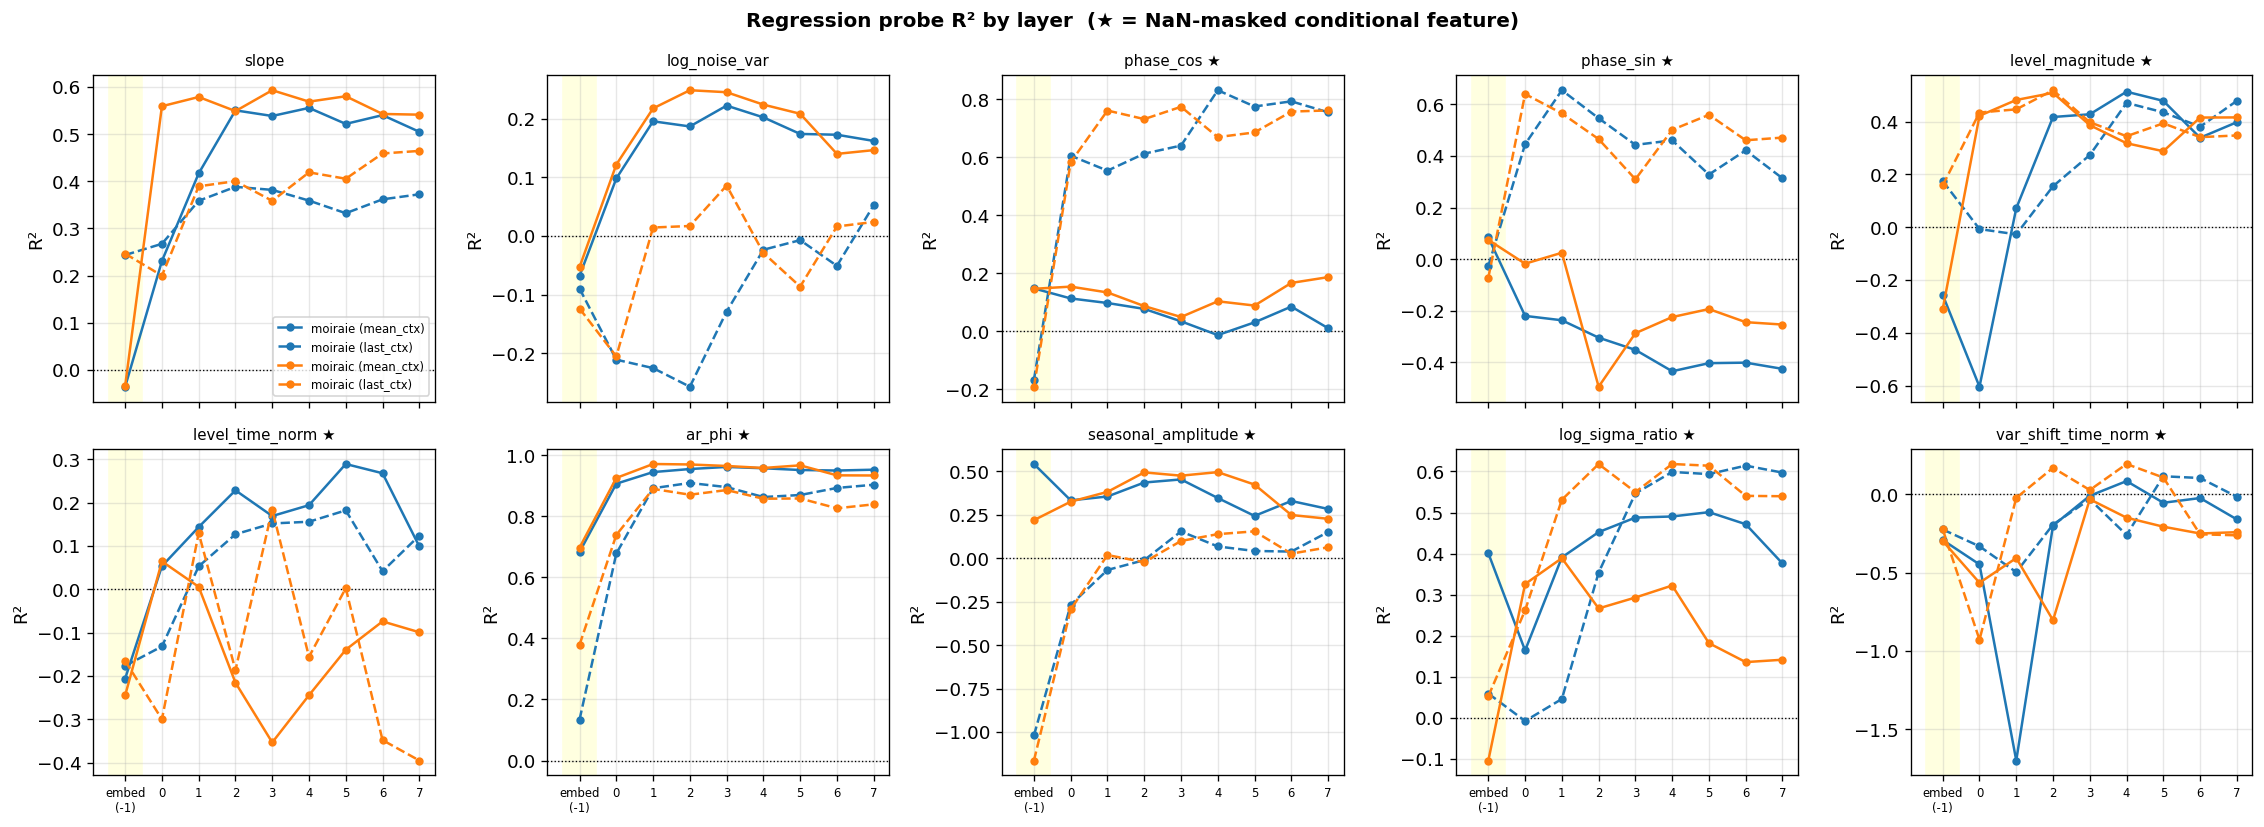

In [5]:
sorted_keys, x_pos, x_labels = layer_x(sample_layers)
embed_xi = x_pos[sorted_keys.index(-1)]

POOLING = 'mean_ctx'   # change to 'last_ctx' for position-31 view

present_reg = [f for f in REGRESSION_FEATURES if any(f in results[m][POOLING] for m in model_names)]
n_feat = len(present_reg)
ncols  = min(5, n_feat)
nrows  = math.ceil(n_feat / ncols)

fig, axes = plt.subplots(nrows, ncols, figsize=(3.8 * ncols, 3.5 * nrows),
                          sharex=True, sharey=False, squeeze=False)

for idx_f, feature in enumerate(present_reg):
    ax = axes[idx_f // ncols][idx_f % ncols]
    ax.axhline(0, color='black', linewidth=0.8, linestyle=':')
    ax.axvspan(embed_xi - 0.45, embed_xi + 0.45, color='lightyellow', zorder=0)

    for model_name in model_names:
        color = model_colors[model_name]
        for pooling in POOLING_MODES:
            layer_scores = results[model_name][pooling].get(feature, {})
            if not layer_scores:
                continue
            keys   = sorted(layer_scores)
            scores = [layer_scores[k] for k in keys]
            xs     = [x_pos[sorted_keys.index(k)] for k in keys]
            ax.plot(xs, scores, marker='o', markersize=4,
                    linestyle=POOLING_LS[pooling], color=color, linewidth=1.5,
                    label=f'{model_name} ({pooling})')

    is_cond = feature in CONDITIONAL_FEATURES
    ax.set_title(feature + (' ★' if is_cond else ''), fontsize=9)
    ax.set_xticks(x_pos)
    ax.set_xticklabels(x_labels, fontsize=7)
    ax.set_ylabel('R²')
    ax.grid(True, alpha=0.3)
    if idx_f == 0:
        ax.legend(fontsize=7, loc='lower right')

# Hide unused axes
for idx_f in range(n_feat, nrows * ncols):
    axes[idx_f // ncols][idx_f % ncols].set_visible(False)

fig.suptitle('Regression probe R² by layer  (★ = NaN-masked conditional feature)',
             fontsize=12, fontweight='bold')
plt.tight_layout()
path = os.path.join(FIGURES_DIR, 'regression_probes.pdf')
fig.savefig(path, bbox_inches='tight')
print(f'Saved {path}')
plt.show()
plt.close(fig)

## 4 · Binary AUROC: `spike_present` and `rw_present`

AUROC = 0.5 is the chance baseline (random classifier). Values > 0.5 indicate the model encodes spike/RW presence.

If running with checkpoints: compare these curves to the R² curves to gauge relative difficulty.

In [ ]:
sorted_keys, x_pos, x_labels = layer_x(sample_layers)
embed_xi = x_pos[sorted_keys.index(-1)]

present_bin = [f for f in BINARY_FEATURES
               if any(f in results[m][POOLING_MODES[0]] for m in model_names)]

if not present_bin:
    print('No binary features found in results (spike_present / rw_present absent from dataset).')
else:
    fig, axes = plt.subplots(1, len(present_bin),
                             figsize=(5.5 * len(present_bin), 4.5),
                             sharey=True, squeeze=False)
    axes = axes[0]

    for ax, feature in zip(axes, present_bin):
        ax.axhline(0.5, color='red', linestyle=':', linewidth=1.0, label='Chance (AUROC=0.5)')
        ax.axvspan(embed_xi - 0.45, embed_xi + 0.45, color='lightyellow', zorder=0)

        for model_name in model_names:
            color = model_colors[model_name]
            for pooling in POOLING_MODES:
                layer_scores = results[model_name][pooling].get(feature, {})
                if not layer_scores:
                    continue
                keys   = sorted(layer_scores)
                scores = [layer_scores[k] for k in keys]
                xs     = [x_pos[sorted_keys.index(k)] for k in keys]
                ax.plot(xs, scores, marker='o', markersize=5,
                        linestyle=POOLING_LS[pooling], color=color, linewidth=1.8,
                        label=f'{model_name} ({pooling})')

        ax.set_ylim(0, 1.05)
        ax.set_xticks(x_pos)
        ax.set_xticklabels(x_labels, fontsize=9)
        ax.set_xlabel('Layer')
        ax.set_ylabel('AUROC')
        ax.set_title(feature, fontsize=11, fontweight='bold')
        ax.legend(fontsize=8, loc='lower right')
        ax.grid(True, alpha=0.3)

    fig.suptitle('Binary features: AUROC by layer  (chance = 0.5)',
                 fontsize=12, fontweight='bold')
    plt.tight_layout()
    path = os.path.join(FIGURES_DIR, 'binary_auroc.pdf')
    fig.savefig(path, bbox_inches='tight')
    print(f'Saved {path}')
    plt.show()
    plt.close(fig)

## 5 · Classification probes: `period_idx`

8-class classification (one of 8 period bins). Chance = 12.5%. `period_idx` uses -1 as absent sentinel — NaN masking filters those rows.

In [ ]:
sorted_keys, x_pos, x_labels = layer_x(sample_layers)
embed_xi = x_pos[sorted_keys.index(-1)]

present_clf = [f for f in ['period_idx']
               if any(f in results[m][POOLING_MODES[0]] for m in model_names)]

if not present_clf:
    print('No classification features found in results.')
else:
    fig, axes = plt.subplots(1, len(present_clf),
                             figsize=(5.5 * len(present_clf), 4.5),
                             sharey=True, squeeze=False)
    axes = axes[0]

    for ax, feature in zip(axes, present_clf):
        meta = FEATURE_META.get(feature, {})
        baseline = meta.get('baseline', 0.0)
        ax.axhline(baseline, color='red', linestyle=':', linewidth=1.0,
                   label=f'Chance ({baseline:.3g})')
        ax.axvspan(embed_xi - 0.45, embed_xi + 0.45, color='lightyellow', zorder=0)

        for model_name in model_names:
            color = model_colors[model_name]
            for pooling in POOLING_MODES:
                layer_scores = results[model_name][pooling].get(feature, {})
                if not layer_scores:
                    continue
                keys   = sorted(layer_scores)
                scores = [layer_scores[k] for k in keys]
                xs     = [x_pos[sorted_keys.index(k)] for k in keys]
                ax.plot(xs, scores, marker='o', markersize=5,
                        linestyle=POOLING_LS[pooling], color=color, linewidth=1.8,
                        label=f'{model_name} ({pooling})')

        ax.set_ylim(0, 1.05)
        ax.set_xticks(x_pos)
        ax.set_xticklabels(x_labels, fontsize=9)
        ax.set_xlabel('Layer')
        ax.set_ylabel('Accuracy')
        ax.set_title(feature, fontsize=11, fontweight='bold')
        ax.legend(fontsize=8, loc='lower right')
        ax.grid(True, alpha=0.3)

    fig.suptitle('Classification probes: accuracy by layer', fontsize=12, fontweight='bold')
    plt.tight_layout()
    path = os.path.join(FIGURES_DIR, 'classification_probes.pdf')
    fig.savefig(path, bbox_inches='tight')
    print(f'Saved {path}')
    plt.show()
    plt.close(fig)

## 6 · Per-patch spike localization heatmap

For each `(layer, context_patch_position)` cell, the score is the **AUROC** for detecting that position `p` is the spike patch (binary: `spike_patch_idx == p`).

A trained model that localizes spikes should show a **diagonal band** — the probe score is high at position `p` in the representation of layer `l` near where the spike actually is.

In [ ]:
if not pp_results:
    print('No per-patch results available. Re-run train_probes.py with --per-patch, or'
          ' the inline fallback above will compute them.')
else:
    for model_name, pp in pp_results.items():
        feat = 'spike_patch_idx'
        if feat not in pp:
            print(f'  {model_name}: spike_patch_idx not in per-patch results — skipping.')
            continue

        layer_dict = pp[feat]
        sorted_layers = sorted(layer_dict.keys())
        n_layers  = len(sorted_layers)
        n_patches = CONTEXT_PATCHES

        # Build heatmap matrix: rows = layers, cols = patch positions
        heat = np.zeros((n_layers, n_patches))
        for row_i, layer_idx in enumerate(sorted_layers):
            patch_dict = layer_dict[layer_idx]
            for p in range(n_patches):
                heat[row_i, p] = patch_dict.get(p, float('nan'))

        y_labels = ['embed\n(-1)' if l == -1 else str(l) for l in sorted_layers]

        fig, ax = plt.subplots(figsize=(12, 0.55 * n_layers + 1.5))
        im = ax.imshow(heat, aspect='auto', interpolation='nearest',
                       cmap='viridis', vmin=0.4, vmax=1.0)
        plt.colorbar(im, ax=ax, label='AUROC')
        ax.axhline(0.5, color='white', linestyle=':', linewidth=0.8, alpha=0.5)

        ax.set_yticks(range(n_layers))
        ax.set_yticklabels(y_labels, fontsize=8)
        ax.set_xlabel('Context patch position')
        ax.set_ylabel('Layer')
        ax.set_title(f'{model_name}: spike_patch_idx per-patch AUROC\n'
                     f'(row=layer, col=context position; AUROC for "this patch is the spike patch")',
                     fontsize=10)

        # Add 0.5 chance contour
        ax.contour(heat, levels=[0.5], colors='white', linewidths=0.5, alpha=0.5)

        plt.tight_layout()
        path = os.path.join(FIGURES_DIR, f'{model_name}_spike_patch_heatmap.pdf')
        fig.savefig(path, bbox_inches='tight')
        print(f'Saved {path}')
        plt.show()
        plt.close(fig)

## 7 · Per-patch spike AUROC profile by layer

Line plot version of the heatmap: one curve per layer, x = context patch position.  
A sharp peak at a consistent position indicates the model spatially localizes spikes.

In [ ]:
if not pp_results:
    print('No per-patch results available.')
else:
    for model_name, pp in pp_results.items():
        feat = 'spike_patch_idx'
        if feat not in pp:
            continue

        layer_dict    = pp[feat]
        sorted_layers = sorted(layer_dict.keys())
        n_layers      = len(sorted_layers)
        cmap          = plt.cm.viridis

        fig, ax = plt.subplots(figsize=(10, 4.5))
        ax.axhline(0.5, color='black', linestyle=':', linewidth=0.8, label='Chance (0.5)')

        for row_i, layer_idx in enumerate(sorted_layers):
            color  = cmap(row_i / max(n_layers - 1, 1))
            label  = 'embed (-1)' if layer_idx == -1 else f'layer {layer_idx}'
            scores = [layer_dict[layer_idx].get(p, float('nan')) for p in range(CONTEXT_PATCHES)]
            ax.plot(range(CONTEXT_PATCHES), scores, linewidth=1.2,
                    color=color, label=label, alpha=0.85)

        sm = plt.cm.ScalarMappable(cmap=cmap,
                                    norm=plt.Normalize(vmin=sorted_layers[0], vmax=sorted_layers[-1]))
        sm.set_array([])
        plt.colorbar(sm, ax=ax, label='Layer index')

        ax.set_xlabel('Context patch position')
        ax.set_ylabel('AUROC (binary: is this the spike patch?)')
        ax.set_title(f'{model_name}: spike localization per context position\n'
                     f'(colour = layer depth; darker = deeper)', fontsize=10)
        ax.legend(fontsize=7, loc='upper left', ncol=2, bbox_to_anchor=(1.15, 1))
        ax.grid(True, alpha=0.3)
        plt.tight_layout()

        path = os.path.join(FIGURES_DIR, f'{model_name}_spike_patch_profile.pdf')
        fig.savefig(path, bbox_inches='tight')
        print(f'Saved {path}')
        plt.show()
        plt.close(fig)

## 8 · Summary table

Peak score per (model, pooling, feature) with metric, baseline, and embed fraction.

In [ ]:
all_feature_types = [
    (f, 'regression') for f in REGRESSION_FEATURES
] + [
    (f, 'binary') for f in BINARY_FEATURES
] + [
    ('period_idx', 'classification'),
]

rows = []
for model_name in model_names:
    for pooling in POOLING_MODES:
        for feature, ftype in all_feature_types:
            ls = results[model_name][pooling].get(feature, {})
            if not ls:
                continue
            meta     = FEATURE_META.get(feature, {})
            embed    = ls.get(-1, float('nan'))
            peak     = max(ls.values())
            best_l   = max((k for k in ls if k >= 0), key=ls.get, default=-1)
            baseline = meta.get('baseline', 0.0)
            metric   = meta.get('metric', '?')
            rows.append({
                'Model':      model_name,
                'Pooling':    pooling,
                'Feature':    feature,
                'Type':       ftype,
                'Metric':     metric,
                'Baseline':   round(baseline, 4),
                'Embed (-1)': round(embed, 4),
                'Peak':       round(peak, 4),
                'Best layer': best_l,
                '↑ above baseline': round(peak - baseline, 4),
            })

df = pd.DataFrame(rows)
path = os.path.join(FIGURES_DIR, 'pr8_summary.csv')
df.to_csv(path, index=False)
print(f'Saved {path}\n')
df.sort_values(['Type', 'Feature', 'Model', 'Pooling'])

## Interpretation guide

| Observation | Interpretation |
|---|---|
| **Conditional R² finite and > 0** | NaN masking is working; features like `ar_phi` are genuinely recoverable |
| **Conditional R² ≈ 0** | Either too few examples or the feature is hard; check NaN fraction in cell 1 |
| **Binary AUROC > 0.5** | Model encodes spike/RW presence; chance baseline is 0.5 |
| **Heatmap diagonal band** | Model spatially localizes spikes — representation at position `p` responds to spike at `p` |
| **Heatmap uniform** | No spatial encoding; spike position not represented at this layer |
| **Deep layers improve AUROC** | Spike localization is a higher-order feature constructed across layers |